# Chapter 4 — Forecasting Model Comparison (Corrected)

This notebook consolidates the results from all eight forecasting models
(Persistence, ARIMA, SARIMA, SARIMAX, Random Forest, XGBoost, LightGBM, LSTM)
across 3 historical periods (FULL, POST_2020, POST_2021), 3 targets
(Solar, Wind Onshore, Wind Offshore), and 5 horizons (1, 6, 24, 72, 168 hours).

**What changed from the previous version of this notebook**

1. **No more dropping rows with R^2 < 0 before averaging.** Filtering per model
   before computing the mean lets weak models discard their worst
   configurations while strong models (which rarely produce R^2 < 0) get
   judged on their full, harder distribution. This inverted the ranking in the
   previous version - SARIMA/SARIMAX only survived in ~20% of configurations
   (their easiest cases) and looked like the *best* models, when across all
   configurations they are actually the *worst*. The full, unfiltered
   comparison is now the primary result. R^2 < 0 is reported instead as a
   **stability diagnostic** (how often a model fails), not used to exclude
   data from the averages.
2. **Two scale-independent metrics are added** so results can be safely
   pooled across the three targets, which differ in generation scale by
   roughly 4-5x:
   - **Skill score vs. Persistence** (`1 - RMSE_model / RMSE_persistence`),
     useful for a baseline-relative "does this beat the naive approach" view.
   - **Normalized RMSE (nRMSE)**, by mean actual generation and by mean
     installed capacity, using descriptive statistics pulled from
     `03_EDA.html` (full-dataset means, 2015-01-01 to 2026-03-31). This is
     the metric most directly comparable to the nRMSE figures reported in
     the literature reviewed in Chapter 2 (e.g. Couto & Estanqueiro, 2022).
   Raw RMSE is still used for comparisons *within* a single target, where it
   remains valid and more interpretable than either normalized measure.


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)


## 1. Load raw model results

In [26]:
results_dir = "results"

validation_df = pd.read_csv(f"{results_dir}/validation_results.csv")   # Persistence, RF, XGBoost, LightGBM
arima_df      = pd.read_csv(f"{results_dir}/arima_results.csv")        # ARIMA, SARIMA, SARIMAX
lstm_raw_df   = pd.read_csv(f"{results_dir}/lstm_results.csv")         # LSTM, all epoch settings

numeric_cols = ["MAE", "RMSE", "MAPE", "R2"]
arima_df[numeric_cols] = arima_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("validation_results:", validation_df.shape)
print("arima_results:     ", arima_df.shape)
print("lstm_results:       ", lstm_raw_df.shape)


validation_results: (180, 8)
arima_results:      (135, 8)
lstm_results:        (225, 9)


### 1.1 Select the best LSTM epoch setting per configuration

For each (Period, Target, Horizon), the epoch setting (20/40/60/80/100) with
the lowest validation RMSE is kept, exactly as described in Section 3.5.3 of
the methodology. This is recomputed here from the raw per-epoch results so
the notebook is self-contained and reproducible from source data.


In [27]:
best_lstm_df = (
    lstm_raw_df
    .loc[lstm_raw_df.groupby(["Period", "Target", "Horizon"])["RMSE"].idxmin()]
    .drop(columns=["Epochs"])
    .reset_index(drop=True)
)

print("best_lstm_df:", best_lstm_df.shape)
best_lstm_df.head()


best_lstm_df: (45, 8)


,Period,Target,Horizon,Model,MAE,RMSE,MAPE,R2
0,FULL,Solar,1,LSTM,422.977549,758.602883,665.381193,0.994059
1,FULL,Solar,6,LSTM,1176.750211,2156.634335,2678.298476,0.951984
2,FULL,Solar,24,LSTM,1505.825810,2841.549972,2001.144952,0.916642
3,FULL,Solar,72,LSTM,2232.319667,3695.451194,10992.565233,0.859017
4,FULL,Solar,168,LSTM,2165.183462,4092.128412,3390.103659,0.827150


**Note on LSTM evaluation (carried over from Chapter 3, Section 3.8):** the
epoch setting above is selected using the same validation set on which its
RMSE is then reported. The other seven models were configured in advance
without any search over the validation set, so the LSTM's reported numbers
are not on fully equal footing with the rest - this asymmetry should be
stated explicitly as a limitation in Chapter 4/5, and ideally resolved by
scoring the selected epoch on the held-out test partition instead, once that
data is available.


## 2. Build the master results table (all models, all configurations, unfiltered)

In [28]:
master_df = pd.concat(
    [validation_df, arima_df, best_lstm_df],
    ignore_index=True
)

master_df = master_df.sort_values(
    ["Period", "Target", "Horizon", "Model"]
).reset_index(drop=True)

print(f"Master table: {master_df.shape[0]} rows, {master_df['Model'].nunique()} models")
print(master_df.groupby("Model").size().rename("n_configs"))

master_df.head()


Master table: 360 rows, 8 models
Model
ARIMA           45
LSTM            45
LightGBM        45
Persistence     45
RandomForest    45
SARIMA          45
SARIMAX         45
XGBoost         45
Name: n_configs, dtype: int64


,Period,Target,Horizon,Model,MAE,RMSE,MAPE,R2
0,FULL,Solar,1,ARIMA,2115.528801,3485.261148,3225.381759,0.874362
1,FULL,Solar,1,LSTM,422.977549,758.602883,665.381193,0.994059
2,FULL,Solar,1,LightGBM,483.089774,934.209202,215.310986,0.990973
3,FULL,Solar,1,Persistence,3335.302917,5549.044824,2197.879204,0.681516
4,FULL,Solar,1,RandomForest,634.612602,1236.341074,28.890315,0.984190


## 3. Model stability diagnostic (R^2 < 0 rate)

This replaces the previous "drop R^2 < 0 rows" step. Instead of excluding
failures from the averages, the failure rate itself is reported as a
diagnostic of how *reliable* each model is across the full range of
conditions tested.


In [29]:
stability = (
    master_df
    .assign(failed=lambda d: d["R2"] < 0)
    .groupby("Model")
    .agg(
        n_configs=("R2", "count"),
        n_failed=("failed", "sum"),
        failure_rate_pct=("failed", lambda s: round(100 * s.mean(), 1)),
        mean_R2=("R2", "mean"),
    )
    .sort_values("failure_rate_pct")
)

stability


,n_configs,n_failed,failure_rate_pct,mean_R2
Model,,,,
LightGBM,45,7,15.6,0.553281
RandomForest,45,7,15.6,0.551695
XGBoost,45,8,17.8,0.549503
LSTM,45,16,35.6,0.439850
Persistence,45,21,46.7,0.027583
ARIMA,45,36,80.0,-2.353626
SARIMA,45,36,80.0,-2.866488
SARIMAX,45,36,80.0,-3.375050


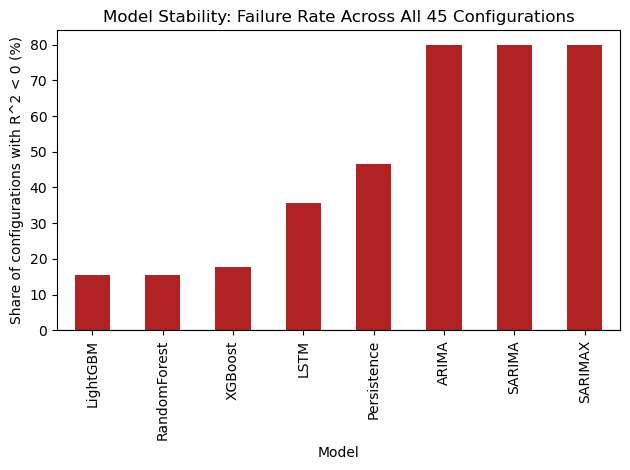

In [30]:
stability["failure_rate_pct"].plot(kind="bar", color="firebrick")
plt.ylabel("Share of configurations with R^2 < 0 (%)")
plt.title("Model Stability: Failure Rate Across All 45 Configurations")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("results/fig_stability_failure_rate.png", dpi=150)
plt.show()


**Reading this table:** a model with a high failure rate should not be
treated as competitive even if its mean RMSE over the *surviving* configs
looks good - that was exactly the artefact in the previous version of this
analysis. ARIMA-family models failing in the large majority of configurations
is itself an important finding for Chapter 4/5 (their fixed (1,1,1)(1,1,1,24)
specification, applied uniformly per Section 3.5.1, does not generalise
across most target/horizon/period combinations).


## 4. Primary model ranking - full, unfiltered comparison

Mean RMSE, MAE, and R^2 computed over **all** configurations per model (no
filtering). This is the headline comparison for Chapter 4.


In [31]:
model_ranking_full = (
    master_df
    .groupby("Model")
    .agg(
        n_configs=("RMSE", "count"),
        RMSE=("RMSE", "mean"),
        MAE=("MAE", "mean"),
        R2=("R2", "mean"),
    )
    .sort_values("RMSE")
    .round(2)
)

model_ranking_full


,n_configs,RMSE,MAE,R2
Model,,,,
LightGBM,45,3777.15,2674.79,0.55
XGBoost,45,3791.13,2678.36,0.55
RandomForest,45,3819.87,2686.99,0.55
LSTM,45,4179.33,3010.03,0.44
Persistence,45,6241.00,4433.60,0.03
ARIMA,45,6613.55,5025.79,-2.35
SARIMA,45,6720.91,5095.42,-2.87
SARIMAX,45,6895.83,5350.29,-3.38


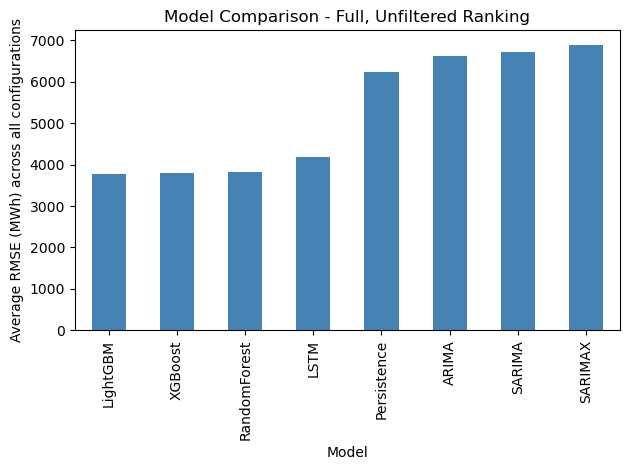

In [32]:
model_ranking_full["RMSE"].plot(kind="bar", color="steelblue")
plt.ylabel("Average RMSE (MWh) across all configurations")
plt.title("Model Comparison - Full, Unfiltered Ranking")
plt.tight_layout()
plt.savefig("results/fig_model_ranking_full.png", dpi=150)
plt.show()


**Caution on this raw-RMSE ranking:** because RMSE is pooled across three
targets with very different generation magnitudes (see Section 5 below), this
ranking is influenced by scale as well as accuracy. It is included because
it is the most direct, literal reading of the pipeline's output, but the
normalized rankings in Sections 6-7 are the more defensible cross-target
comparisons and should be treated as the primary basis for conclusions in
Chapter 4/5.


## 5. Why raw RMSE cannot be pooled across targets

Solar, Wind Onshore, and Wind Offshore generation differ substantially in
scale. Averaging RMSE across targets without accounting for this means the
comparison is dominated by whichever target has the largest absolute values,
not by which model is actually more accurate.


In [33]:
target_scale = (
    master_df
    .groupby("Target")
    .agg(
        mean_RMSE=("RMSE", "mean"),
        mean_MAE=("MAE", "mean"),
    )
    .round(1)
)

target_scale["scale_ratio_vs_smallest"] = (
    target_scale["mean_RMSE"] / target_scale["mean_RMSE"].min()
).round(2)

target_scale


,mean_RMSE,mean_MAE,scale_ratio_vs_smallest
Target,,,
Solar,4679.8,2833.9,2.43
Wind_Offshore,1924.1,1556.0,1.00
Wind_Onshore,9160.7,7218.3,4.76


## 6. Forecast skill score relative to Persistence (scale-independent)

For each (Period, Target, Horizon), the skill score of every model is
computed relative to the Persistence baseline evaluated on that exact
combination:

`Skill = 1 - RMSE_model / RMSE_persistence`

A skill score of 0 means "no better than persistence"; 1 means "no error";
negative values mean "worse than the naive baseline." Because the
Persistence RMSE itself scales with the volatility of that specific
target/horizon/period, dividing by it removes the cross-target scale problem
identified above, so skill scores can be safely averaged across targets.


In [34]:
persistence_lookup = (
    master_df[master_df["Model"] == "Persistence"]
    .set_index(["Period", "Target", "Horizon"])["RMSE"]
)

master_df["Persistence_RMSE"] = master_df.set_index(
    ["Period", "Target", "Horizon"]
).index.map(persistence_lookup)

master_df["Skill_vs_Persistence"] = (
    1 - master_df["RMSE"] / master_df["Persistence_RMSE"]
)

master_df[["Period", "Target", "Horizon", "Model", "RMSE", "Persistence_RMSE", "Skill_vs_Persistence"]].head(10)


,Period,Target,Horizon,Model,RMSE,Persistence_RMSE,Skill_vs_Persistence
0,FULL,Solar,1,ARIMA,3485.261148,5549.044824,0.371917
1,FULL,Solar,1,LSTM,758.602883,5549.044824,0.863291
2,FULL,Solar,1,LightGBM,934.209202,5549.044824,0.831645
3,FULL,Solar,1,Persistence,5549.044824,5549.044824,0.000000
4,FULL,Solar,1,RandomForest,1236.341074,5549.044824,0.777197
5,FULL,Solar,1,SARIMA,2979.794869,5549.044824,0.463008
6,FULL,Solar,1,SARIMAX,2963.339609,5549.044824,0.465973
7,FULL,Solar,1,XGBoost,963.351984,5549.044824,0.826393
8,FULL,Solar,6,ARIMA,15517.869797,16434.163505,0.055755
9,FULL,Solar,6,LSTM,2156.634335,16434.163505,0.868771


In [35]:
skill_ranking = (
    master_df[master_df["Model"] != "Persistence"]
    .groupby("Model")
    .agg(
        n_configs=("Skill_vs_Persistence", "count"),
        mean_skill=("Skill_vs_Persistence", "mean"),
        median_skill=("Skill_vs_Persistence", "median"),
    )
    .sort_values("mean_skill", ascending=False)
    .round(3)
)

skill_ranking


,n_configs,mean_skill,median_skill
Model,,,
LightGBM,45,0.313,0.237
XGBoost,45,0.311,0.232
RandomForest,45,0.306,0.238
LSTM,45,0.242,0.175
ARIMA,45,-0.076,0.056
SARIMA,45,-0.087,-0.007
SARIMAX,45,-0.190,-0.101


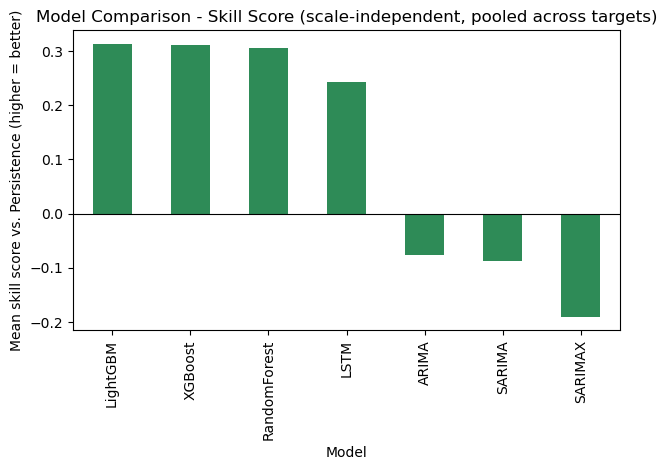

In [36]:
skill_ranking["mean_skill"].plot(kind="bar", color="seagreen")
plt.ylabel("Mean skill score vs. Persistence (higher = better)")
plt.title("Model Comparison - Skill Score (scale-independent, pooled across targets)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("results/fig_model_ranking_skill.png", dpi=150)
plt.show()


## 7. Normalized RMSE (nRMSE) - literature-comparable metric

Skill score answers "better than the naive baseline?" nRMSE answers "what
fraction of typical output does the forecast miss by?" - the metric most
directly comparable to values reported in the literature reviewed in
Chapter 2 (e.g. Couto & Estanqueiro, 2022 report normalized wind forecasting
error reductions of 13-37%).

Two normalizers are used, both taken from the full-dataset descriptive
statistics in `03_EDA.html` (2015-01-01 to 2026-03-31):

- **nRMSE (mean generation)** = RMSE / mean actual hourly generation for that
  target
- **nRMSE (installed capacity)** = RMSE / mean installed capacity for that
  target

The capacity-based version is generally preferred in the literature because
capacity is a fixed physical reference rather than a value that itself
depends on weather/output conditions, but both are reported here since your
own dataset's capacity grew substantially over the study period (e.g.
offshore wind capacity roughly tripled between 2015 and 2023, per Section
3.3.1 of the methodology), so the capacity figure is itself a period-average
approximation.


In [37]:
# Full-dataset descriptive statistics, extracted from 03_EDA.html
mean_generation = {
    "Solar":         5477.915011,   # generation_photovoltaics_mwh
    "Wind_Onshore":  10888.026035,  # generation_wind_onshore_mwh
    "Wind_Offshore": 2452.882705,   # generation_wind_offshore_mwh
}

mean_capacity = {
    "Solar":         54333.986103,  # capacity_photovoltaics_mw
    "Wind_Onshore":  52498.654971,  # capacity_wind_onshore_mw
    "Wind_Offshore": 7046.018127,   # capacity_wind_offshore_mw
}

master_df["mean_generation_ref"] = master_df["Target"].map(mean_generation)
master_df["mean_capacity_ref"]   = master_df["Target"].map(mean_capacity)

master_df["nRMSE_generation_pct"] = (
    100 * master_df["RMSE"] / master_df["mean_generation_ref"]
)
master_df["nRMSE_capacity_pct"] = (
    100 * master_df["RMSE"] / master_df["mean_capacity_ref"]
)

master_df[
    ["Period", "Target", "Horizon", "Model", "RMSE",
     "nRMSE_generation_pct", "nRMSE_capacity_pct"]
].head(10)


,Period,Target,Horizon,Model,RMSE,nRMSE_generation_pct,nRMSE_capacity_pct
0,FULL,Solar,1,ARIMA,3485.261148,63.623863,6.414514
1,FULL,Solar,1,LSTM,758.602883,13.848387,1.396185
2,FULL,Solar,1,LightGBM,934.209202,17.054102,1.719383
3,FULL,Solar,1,Persistence,5549.044824,101.298483,10.212843
4,FULL,Solar,1,RandomForest,1236.341074,22.569556,2.275447
5,FULL,Solar,1,SARIMA,2979.794869,54.396515,5.484219
6,FULL,Solar,1,SARIMAX,2963.339609,54.096122,5.453934
7,FULL,Solar,1,XGBoost,963.351984,17.586107,1.773019
8,FULL,Solar,6,ARIMA,15517.869797,283.280587,28.560153
9,FULL,Solar,6,LSTM,2156.634335,39.369620,3.969218


In [38]:
nrmse_ranking = (
    master_df
    .groupby("Model")
    .agg(
        n_configs=("RMSE", "count"),
        nRMSE_generation_pct=("nRMSE_generation_pct", "mean"),
        nRMSE_capacity_pct=("nRMSE_capacity_pct", "mean"),
        mean_R2=("R2", "mean"),
    )
    .sort_values("nRMSE_capacity_pct")
    .round(2)
)

nrmse_ranking


,n_configs,nRMSE_generation_pct,nRMSE_capacity_pct,mean_R2
Model,,,,
LightGBM,45,59.18,13.16,0.55
XGBoost,45,59.42,13.22,0.55
RandomForest,45,59.57,13.22,0.55
LSTM,45,64.76,14.55,0.44
Persistence,45,100.20,19.61,0.03
ARIMA,45,104.29,22.44,-2.35
SARIMA,45,103.08,22.85,-2.87
SARIMAX,45,110.84,23.26,-3.38


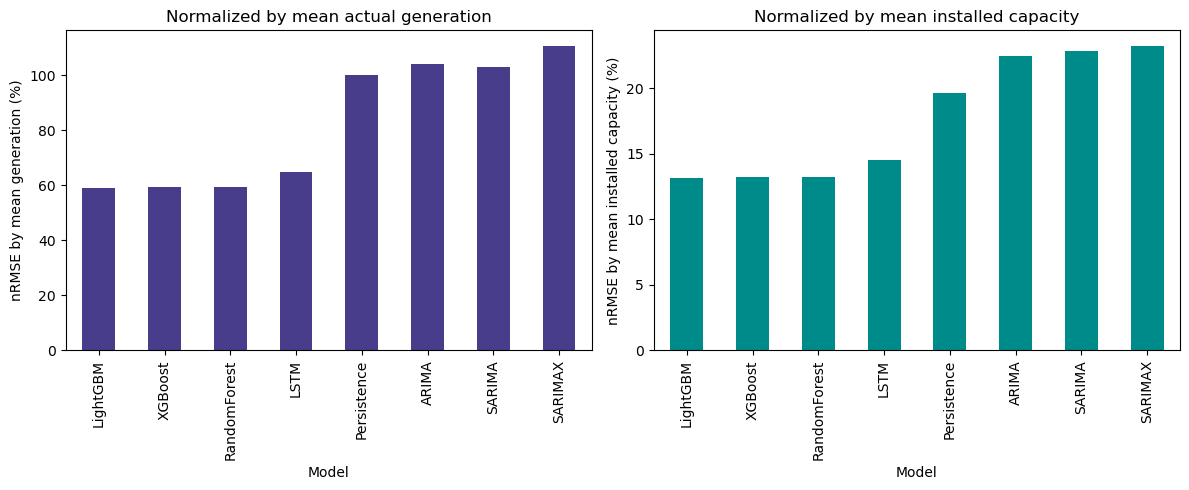

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

nrmse_ranking["nRMSE_generation_pct"].plot(kind="bar", ax=axes[0], color="darkslateblue")
axes[0].set_ylabel("nRMSE by mean generation (%)")
axes[0].set_title("Normalized by mean actual generation")

nrmse_ranking["nRMSE_capacity_pct"].plot(kind="bar", ax=axes[1], color="darkcyan")
axes[1].set_ylabel("nRMSE by mean installed capacity (%)")
axes[1].set_title("Normalized by mean installed capacity")

plt.tight_layout()
plt.savefig("results/fig_model_ranking_nrmse.png", dpi=150)
plt.show()


**Reading nRMSE:** using the Lewis (1982) classification your Chapter 2/3
already adopts for MAPE (below 10% = high accuracy, 10-20% = good, 20-50% =
reasonable, above 50% = inaccurate), the capacity-normalized nRMSE gives you
a directly quotable accuracy classification per model, on the same scale
used throughout the forecasting literature you reviewed.


## 8. Comparison by historical training period

Using the normalized metrics (valid to pool across targets) rather than raw
RMSE.


In [40]:
period_comparison = (
    master_df[master_df["Model"] != "Persistence"]
    .groupby("Period")
    .agg(
        n_configs=("Skill_vs_Persistence", "count"),
        mean_skill=("Skill_vs_Persistence", "mean"),
        mean_nRMSE_generation_pct=("nRMSE_generation_pct", "mean"),
        mean_nRMSE_capacity_pct=("nRMSE_capacity_pct", "mean"),

        mean_R2=("R2", "mean"),
    )
    .sort_values("mean_skill", ascending=False)
    .round(3)
)

period_comparison


,n_configs,mean_skill,mean_nRMSE_generation_pct,mean_nRMSE_capacity_pct,mean_R2
Period,,,,,
POST_2020,105,0.126,79.831,17.275,-0.636
POST_2021,105,0.120,80.316,17.366,-0.643
FULL,105,0.105,80.348,17.949,-1.507


In [41]:
# master_df = master_df[
#     master_df["Period"] == "FULL"
# ].reset_index(drop=True)

# # print(final_results_df.shape)
# master_df

## 9. Comparison by forecasting horizon

Skill score and nRMSE by horizon (pooled across targets and periods),
showing how forecasting advantage over the naive baseline changes as the
horizon extends - directly relevant to the sub-research question on
horizon-based performance variation.


In [42]:
horizon_comparison = (
    master_df[master_df["Model"] != "Persistence"]
    .groupby("Horizon")
    .agg(
        n_configs=("Skill_vs_Persistence", "count"),
        mean_skill=("Skill_vs_Persistence", "mean"),
        mean_nRMSE_capacity_pct=("nRMSE_capacity_pct", "mean"),
        mean_R2=("R2", "mean"),
    )
    .sort_values("Horizon")
    .round(3)
)

horizon_comparison


,n_configs,mean_skill,mean_nRMSE_capacity_pct,mean_R2
Horizon,,,,
1,63,0.290,5.476,0.933
6,63,0.049,20.176,-1.067
24,63,0.086,19.536,-0.332
72,63,0.130,20.727,-0.954
168,63,0.030,21.736,-3.224


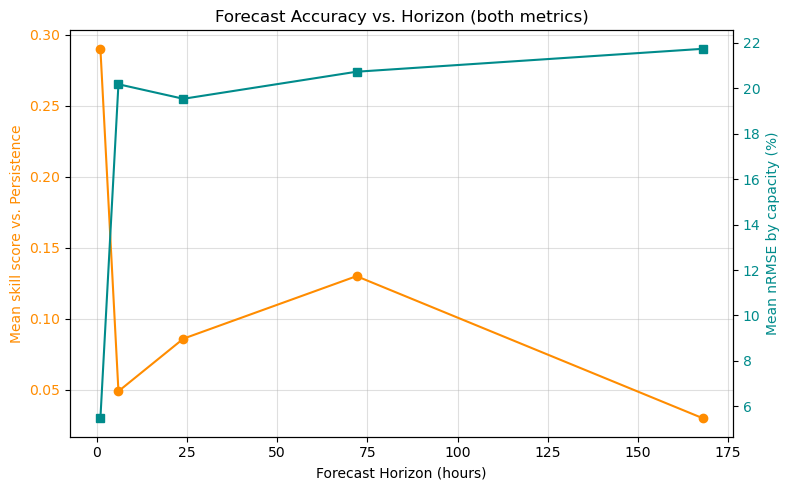

In [43]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(horizon_comparison.index, horizon_comparison["mean_skill"], marker="o", color="darkorange", label="Skill vs. Persistence")
ax1.set_xlabel("Forecast Horizon (hours)")
ax1.set_ylabel("Mean skill score vs. Persistence", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")
ax1.grid(True, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(horizon_comparison.index, horizon_comparison["mean_nRMSE_capacity_pct"], marker="s", color="darkcyan", label="nRMSE (capacity %)")
ax2.set_ylabel("Mean nRMSE by capacity (%)", color="darkcyan")
ax2.tick_params(axis="y", labelcolor="darkcyan")

plt.title("Forecast Accuracy vs. Horizon (both metrics)")
fig.tight_layout()
plt.savefig("results/fig_accuracy_vs_horizon.png", dpi=150)
plt.show()


### 9.1 Which model family leads at each horizon?

Skill score by horizon and model, so the horizon-dependent ranking shift
(short horizons favouring one family, long horizons another) can be read
directly rather than only from the pooled average.


In [44]:
horizon_model_skill = (
    master_df[master_df["Model"] != "Persistence"]
    .pivot_table(index="Horizon", columns="Model", values="Skill_vs_Persistence", aggfunc="mean")
    .round(3)
)

horizon_model_skill


Model,ARIMA,LSTM,LightGBM,RandomForest,SARIMA,SARIMAX,XGBoost
Horizon,,,,,,,
1,0.199,0.300,0.360,0.316,0.245,0.256,0.358
6,-0.633,0.516,0.534,0.521,-0.570,-0.558,0.532
24,-0.069,0.171,0.243,0.246,-0.076,-0.147,0.237
72,0.113,0.150,0.223,0.235,0.074,-0.106,0.220
168,0.013,0.072,0.208,0.212,-0.108,-0.392,0.207


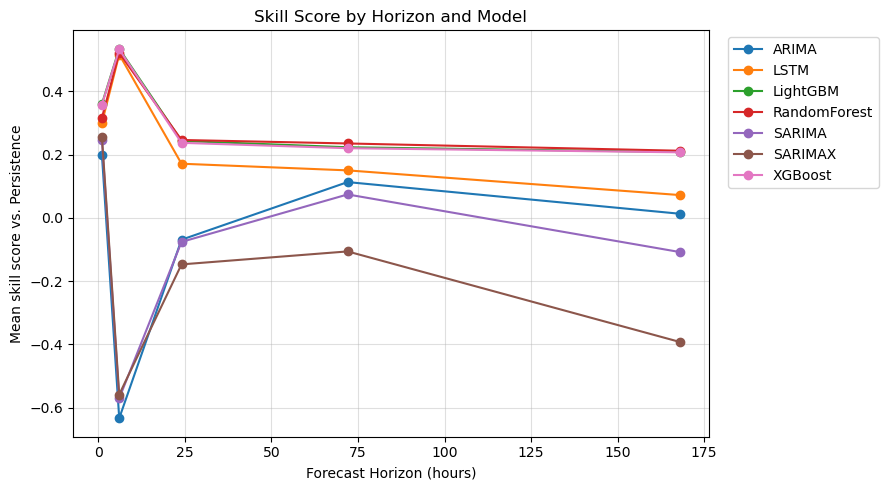

In [45]:
horizon_model_skill.plot(marker="o", figsize=(9, 5))
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Mean skill score vs. Persistence")
plt.title("Skill Score by Horizon and Model")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("results/fig_skill_by_horizon_model.png", dpi=150)
plt.show()


## 10. Comparison by target (raw RMSE is valid *within* a single target)

Unlike the pooled comparisons above, ranking models within a single target
using raw RMSE is legitimate, since all models are being compared on the
same generation scale. The nRMSE-by-capacity column is also shown so
target-level accuracy can be read on a common scale if needed.


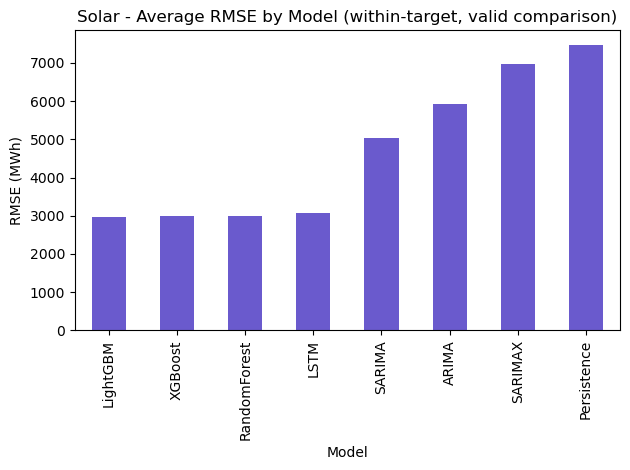

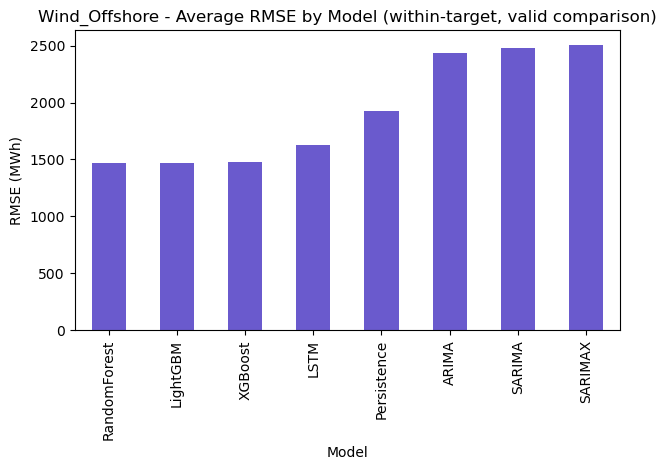

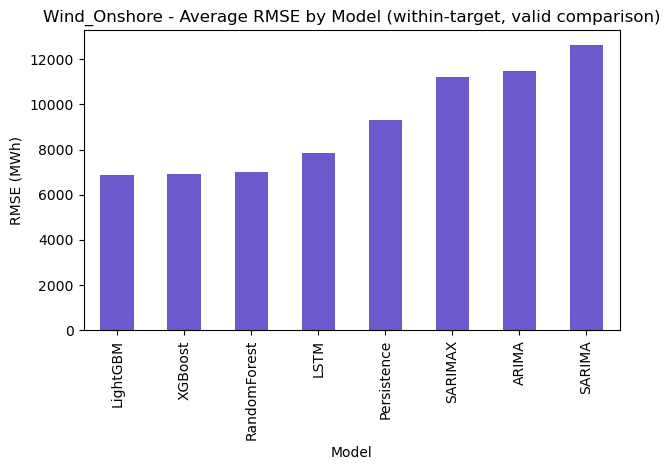

In [46]:
for target in master_df["Target"].unique():
    subset = (
        master_df[master_df["Target"] == target]
        .groupby("Model")["RMSE"]
        .mean()
        .sort_values()
    )

    ax = subset.plot(kind="bar", color="slateblue")
    plt.title(f"{target} - Average RMSE by Model (within-target, valid comparison)")
    plt.ylabel("RMSE (MWh)")
    plt.tight_layout()
    plt.savefig(f"results/fig_rmse_by_model_{target}.png", dpi=150)
    plt.show()


In [47]:
target_model_summary = (
    master_df
    .groupby(["Target", "Model"])
    .agg(
        RMSE=("RMSE", "mean"),
        nRMSE_capacity_pct=("nRMSE_capacity_pct", "mean"),
    )
    .round(2)
    .sort_values(["Target", "RMSE"])
)

target_model_summary


RMSE  nRMSE_capacity_pct
Target        Model                                     
Solar         LightGBM       2971.53                5.47
              XGBoost        2983.95                5.49
              RandomForest   2988.86                5.50
              LSTM           3068.14                5.65
              SARIMA         5040.76                9.28
              ARIMA          5927.37               10.91
              SARIMAX        6977.75               12.84
              Persistence    7479.67               13.77
Wind_Offshore RandomForest   1467.81               20.83
              LightGBM       1472.48               20.90
              XGBoost        1479.98               21.00
              LSTM           1624.43               23.05
              Persistence    1924.51               27.31
              ARIMA          2434.39               34.55
              SARIMA         2480.65               35.21
              SARIMAX        2508.47               35.60
Wind_Onshore  LightGBM       6887.43               13.12
              XGBoost        6909.45               13.16
              RandomForest   7002.96               13.34
              LSTM           7845.42               14.94
              Persistence    9318.82               17.75
              SARIMAX       11201.26               21.34
              ARIMA         11478.89               21.87
              SARIMA        12641.33               24.08

## 11. Best model per (Target, Horizon)

Within a single configuration, raw RMSE is directly comparable across models
(same target, same scale), so this comparison does not need normalization.
Computed here on the full, unfiltered master table.


In [48]:
best_configs = (
    master_df
    .loc[master_df.groupby(["Target", "Horizon"])["RMSE"].idxmin()]
    .sort_values(["Period", "Target", "Horizon"])
    .reset_index(drop=True)
)

print(f"Shape: {best_configs.shape}")
best_configs[["Period", "Target", "Horizon", "Model", "RMSE", "MAE", "R2"]].head(15)


Shape: (15, 14)


,Period,Target,Horizon,Model,RMSE,MAE,R2
0,FULL,Solar,1,LSTM,758.602883,422.977549,0.994059
1,FULL,Solar,6,LSTM,2156.634335,1176.750211,0.951984
2,FULL,Solar,24,SARIMA,2545.491719,1228.853806,-0.287340
3,FULL,Solar,168,SARIMA,1896.488569,977.374047,-0.295032
4,FULL,Wind_Offshore,1,LightGBM,586.214452,417.689133,0.897348
5,FULL,Wind_Offshore,6,RandomForest,1247.603225,956.228865,0.535373
6,FULL,Wind_Offshore,24,RandomForest,1664.718630,1368.847625,0.170291
7,FULL,Wind_Offshore,72,RandomForest,1755.242313,1467.472270,0.077238
8,FULL,Wind_Offshore,168,LightGBM,1756.180348,1450.985102,0.071904
9,FULL,Wind_Onshore,6,LSTM,3957.265214,2948.211863,0.859145


In [49]:
best_model_wins = (
    best_configs["Model"]
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Wins")
)

best_model_wins["Wins_pct"] = (100 * best_model_wins["Wins"] / len(best_configs)).round(1)
best_model_wins


,Model,Wins,Wins_pct
0,LightGBM,4,26.7
1,RandomForest,4,26.7
2,LSTM,3,20.0
3,SARIMA,3,20.0
4,SARIMAX,1,6.7


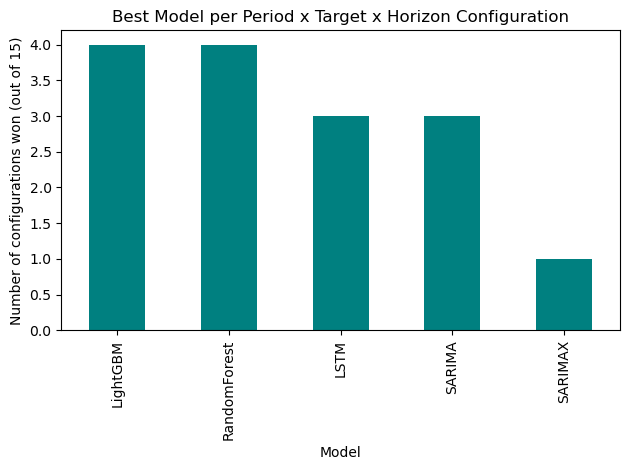

In [50]:
best_model_wins.set_index("Model")["Wins"].plot(kind="bar", color="teal")
plt.ylabel(f"Number of configurations won (out of {len(best_configs)})")
plt.title("Best Model per Period x Target x Horizon Configuration")
plt.tight_layout()
plt.savefig("results/fig_best_model_wins.png", dpi=150)
plt.show()


## 12. Export summary tables

All corrected summary tables are written to a single Excel workbook (one
sheet per table) and the full unfiltered master table is saved to CSV, so
these can be dropped directly into Chapter 4 without re-running the
notebook.


In [51]:
with pd.ExcelWriter("results/chapter4_summary_tables.xlsx") as writer:
    master_df.to_excel(writer, sheet_name="master_all_configs", index=False)
    stability.to_excel(writer, sheet_name="stability_diagnostic")
    model_ranking_full.to_excel(writer, sheet_name="model_ranking_raw_rmse")
    skill_ranking.to_excel(writer, sheet_name="model_ranking_skill_score")
    nrmse_ranking.to_excel(writer, sheet_name="model_ranking_nrmse")
    period_comparison.to_excel(writer, sheet_name="period_comparison")
    horizon_comparison.to_excel(writer, sheet_name="horizon_comparison")
    horizon_model_skill.to_excel(writer, sheet_name="skill_by_horizon_model")
    target_model_summary.to_excel(writer, sheet_name="rmse_nrmse_by_target_model")
    best_configs.to_excel(writer, sheet_name="best_config_per_combo", index=False)
    best_model_wins.to_excel(writer, sheet_name="best_model_win_counts", index=False)

master_df.to_csv("results/master_results_unfiltered.csv", index=False)

print("Exported: results/chapter4_summary_tables.xlsx")
print("Exported: results/master_results_unfiltered.csv")


Exported: results/chapter4_summary_tables.xlsx
Exported: results/master_results_unfiltered.csv


## 13. Summary of key findings (for direct use in Chapter 4/5 text)

- **Primary ranking (skill score and nRMSE, both valid across targets):**
  see Sections 6-7. Report `skill_ranking` and `nrmse_ranking` as the
  headline model comparison tables - skill score for the baseline-relative
  story, nRMSE for direct comparability with the forecasting literature
  reviewed in Chapter 2.
- **Stability finding:** ARIMA/SARIMA/SARIMAX produce negative R^2 in the
  majority of configurations (see Section 3) - report the failure rate
  alongside their skill score/nRMSE, since a model that is only strong in a
  minority of cases should be characterised as unstable, not simply ranked
  by its best-case performance.
- **Horizon finding:** use Section 9 to state how accuracy (both skill score
  and nRMSE) changes from 1-hour to 168-hour horizons, and which model
  family leads at each horizon (Section 9.1) - this directly answers the
  sub-research question on horizon-based performance variation.
- **Target finding:** raw RMSE comparisons in Section 10 are valid only
  within a target; use nRMSE if you need to state which target is inherently
  harder/easier to forecast on a common scale.
- **Outstanding limitation to state explicitly:** the LSTM's epoch setting
  is selected on the same validation data used to report its performance,
  while the other seven models were configured without any such search -
  carry this forward as a stated limitation (Section 1.1 note above) unless
  the held-out test partition is used to re-score LSTM before final
  submission.
- **Normalization methodology note:** the mean generation and mean capacity
  figures used in Section 7 are full-dataset averages (2015-01-01 to
  2026-03-31), taken from `03_EDA.html`. Because installed capacity grew
  substantially over this period (e.g. offshore wind capacity roughly
  tripled), these are period-average approximations rather than period-exact
  normalizers - worth a one-sentence caveat in Chapter 4 if reviewers query
  precision.
